In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu vào dataframe
df = pd.read_csv('/content/Mall_Customers.csv')

# Chuyển đổi thuộc tính Gender thành số: 0 - Male, 1 - Female
df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1})

# Chuyển đổi các thuộc tính Age, Annual Income (k$) và Spending Score (1-100) thành dạng số
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].apply(pd.to_numeric)

# Lấy các thuộc tính đã chuyển đổi thành một ma trận numpy
X = df[['Age', 'Gender', 'Annual Income (k$)', 'Spending Score (1-100)']].values
print(X)

[[ 19   0  15  39]
 [ 21   0  15  81]
 [ 20   1  16   6]
 [ 23   1  16  77]
 [ 31   1  17  40]
 [ 22   1  17  76]
 [ 35   1  18   6]
 [ 23   1  18  94]
 [ 64   0  19   3]
 [ 30   1  19  72]
 [ 67   0  19  14]
 [ 35   1  19  99]
 [ 58   1  20  15]
 [ 24   1  20  77]
 [ 37   0  20  13]
 [ 22   0  20  79]
 [ 35   1  21  35]
 [ 20   0  21  66]
 [ 52   0  23  29]
 [ 35   1  23  98]
 [ 35   0  24  35]
 [ 25   0  24  73]
 [ 46   1  25   5]
 [ 31   0  25  73]
 [ 54   1  28  14]
 [ 29   0  28  82]
 [ 45   1  28  32]
 [ 35   0  28  61]
 [ 40   1  29  31]
 [ 23   1  29  87]
 [ 60   0  30   4]
 [ 21   1  30  73]
 [ 53   0  33   4]
 [ 18   0  33  92]
 [ 49   1  33  14]
 [ 21   1  33  81]
 [ 42   1  34  17]
 [ 30   1  34  73]
 [ 36   1  37  26]
 [ 20   1  37  75]
 [ 65   1  38  35]
 [ 24   0  38  92]
 [ 48   0  39  36]
 [ 31   1  39  61]
 [ 49   1  39  28]
 [ 24   1  39  65]
 [ 50   1  40  55]
 [ 27   1  40  47]
 [ 29   1  40  42]
 [ 31   1  40  42]
 [ 49   1  42  52]
 [ 33   0  42  60]
 [ 31   1  4

<ipython-input-2-f79a42e9f9a1>:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1})


In [3]:
# Hàm tính khoảng cách Euclidean giữa các điểm dữ liệu và centroids
def euclidean_distance(x, centroids):
    return np.sqrt(np.sum((x - centroids)**2, axis=1))

In [4]:
# Hàm tính WCSS cho một số lượng cụm K
def compute_wcss(X, centroids, labels):
    WCSS = 0
    for k in range(len(centroids)):
        cluster_points = X[labels == k]
        centroid = centroids[k]
        distance = euclidean_distance(cluster_points, centroid)
        cluster_wcss = np.sum(distance ** 2)
        WCSS += cluster_wcss
    return WCSS

In [5]:
# Hàm chạy thuật toán K-means
def kmeans(X, K, max_iters=100):
    np.random.seed(42)  # Để kết quả có thể tái lập

    # Khởi tạo ngẫu nhiên các centroids ban đầu
    centroids = X[np.random.choice(X.shape[0], size=K, replace=False)]

    for _ in range(max_iters):
        # Gán nhãn cho từng điểm dữ liệu dựa trên centroids
        labels = np.argmin(np.apply_along_axis(euclidean_distance, 1, X, centroids), axis=1)

        # Cập nhật centroids bằng cách lấy trung bình của các điểm dữ liệu trong cùng một cụm
        new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])

        # Kiểm tra điều kiện dừng: nếu centroids không thay đổi đáng kể, dừng thuật toán
        if np.all(centroids == new_centroids):
            break

        centroids = new_centroids

    return centroids, labels

In [6]:
# Tìm số cụm tối ưu cho mỗi phần
attributes = [['Age', 'Gender'], ['Age', 'Annual Income (k$)'], ['Age', 'Spending Score (1-100)']]
optimal_clusters = []

for attr in attributes:
    # Lấy dữ liệu cho từng cặp thuộc tính
    X_attr = df[attr].values

    # Tính toán WCSS cho các giá trị K khác nhau
    wcss = []
    max_clusters = 3  # Số cụm tối đa để thử
    for k in range(1, max_clusters + 1):
        centroids, labels = kmeans(X_attr, K=k)
        wcss.append(compute_wcss(X_attr, centroids, labels))

    # Tìm điểm "khuỷu tay" để xác định số cụm tối ưu
    diff = np.diff(wcss)
    elbow_index = np.argmax(diff) + 1  # Chỉ số của điểm "khuỷu tay"
    optimal_clusters.append(elbow_index + 1)  # Số cụm tối ưu

# In số cụm tối ưu cho từng cặp thuộc tính
for i, attr in enumerate(attributes):
    print(f"Số cụm tối ưu cho {attr}: {optimal_clusters[i]}")

    # Gán nhãn cụm cho DataFrame
    df['Cluster'] = labels

    # Tính thống kê trung bình của từng cụm
    cluster_stats = df.groupby('Cluster')[attr].mean()
    print(cluster_stats)

Số cụm tối ưu cho ['Age', 'Gender']: 3
               Age    Gender
Cluster                     
0        43.054945  0.604396
1        29.564516  0.548387
2        42.957447  0.489362
Số cụm tối ưu cho ['Age', 'Annual Income (k$)']: 3
               Age  Annual Income (k$)
Cluster                               
0        43.054945           54.340659
1        29.564516           64.661290
2        42.957447           67.191489
Số cụm tối ưu cho ['Age', 'Spending Score (1-100)']: 3
               Age  Spending Score (1-100)
Cluster                                   
0        43.054945               47.780220
1        29.564516               80.741935
2        42.957447               14.595745


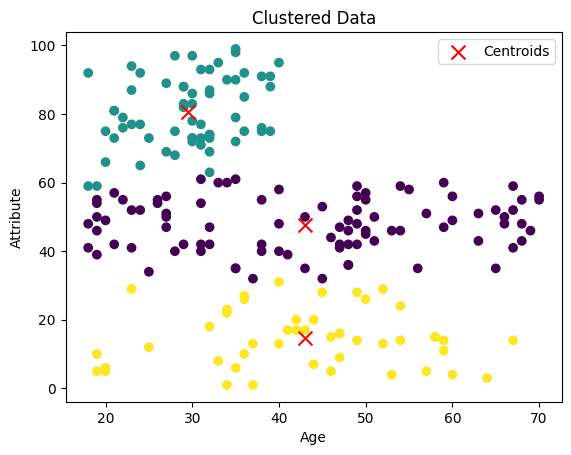

In [8]:
# Trực quan hóa kết quả phân cụm cho tất cả các điểm dữ liệu
plt.scatter(X_attr[:, 0], X_attr[:, 1], c=labels, cmap='viridis')  # Vẽ các điểm dữ liệu với màu sắc theo nhãn cụm
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=100, label='Centroids')  # Vẽ các tâm cụm
plt.legend()
plt.xlabel('Age')
plt.ylabel('Attribute')
plt.title('Clustered Data')
plt.show()

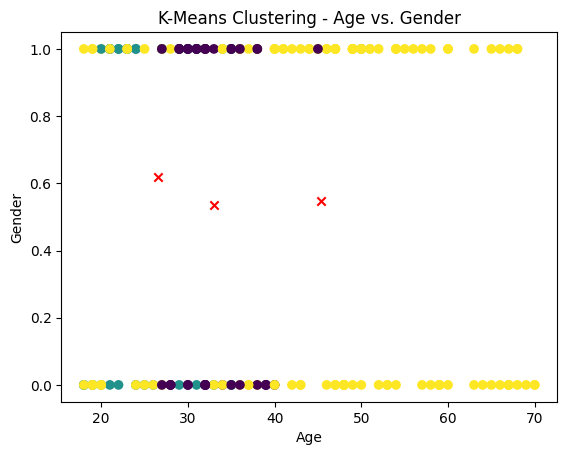

In [13]:
# Trực quan hóa kết quả phân cụm cho cặp thuộc tính 'Age' và 'Gender'
centroids, labels = kmeans(X, K=optimal_clusters[0])  # Phân cụm cho 'Age' và 'Gender'
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x')
plt.xlabel('Age')
plt.ylabel('Gender')
plt.title('K-Means Clustering - Age vs. Gender')
plt.show()

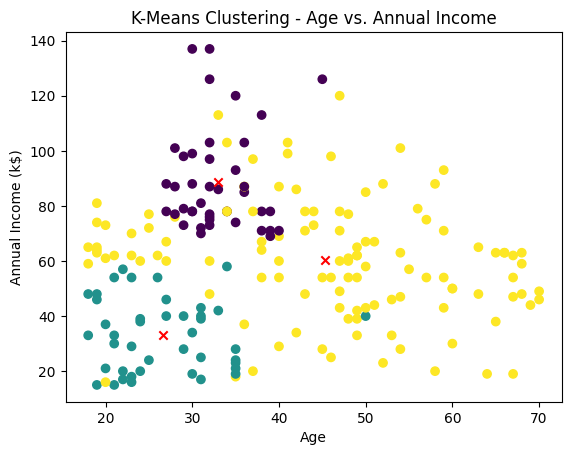

In [14]:
# Trực quan hóa kết quả phân cụm cho cặp thuộc tính 'Age' và 'Annual Income (k$)'
centroids, labels = kmeans(X, K=optimal_clusters[1])  # Phân cụm cho 'Age' và 'Annual Income (k$)'
plt.scatter(X[:, 0], X[:, 2], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 2], c='red', marker='x')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('K-Means Clustering - Age vs. Annual Income')
plt.show()

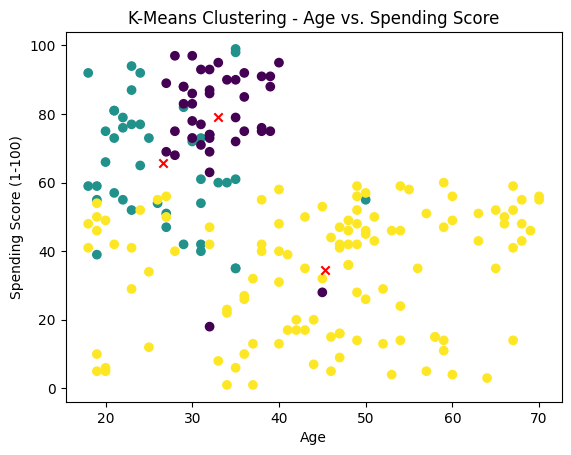

In [15]:
# Trực quan hóa kết quả phân cụm cho cặp thuộc tính 'Age' và 'Spending Score (1-100)'
centroids, labels = kmeans(X, K=optimal_clusters[2])  # Phân cụm cho 'Age' và 'Spending Score (1-100)'
plt.scatter(X[:, 0], X[:, 3], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 3], c='red', marker='x')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering - Age vs. Spending Score')
plt.show()

<ipython-input-5-789d37df5c71>:13: RuntimeWarning: Mean of empty slice.
  new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


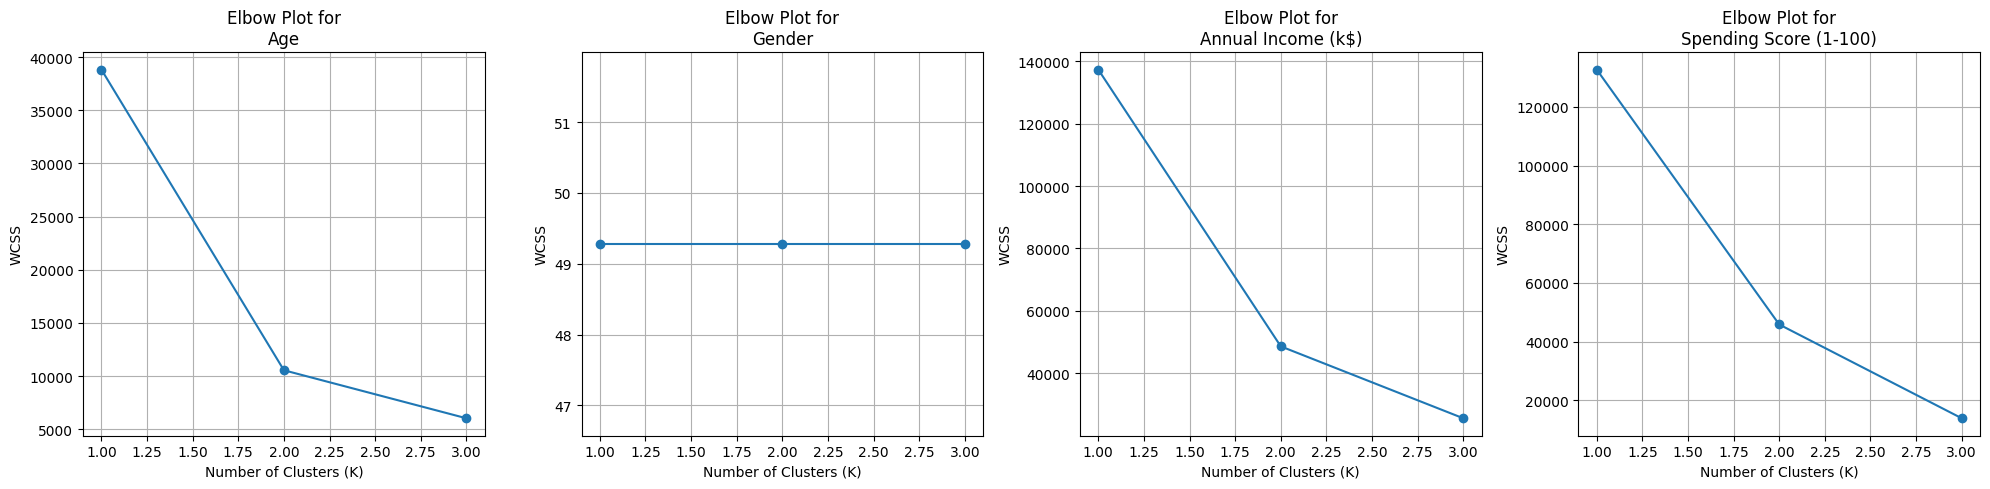

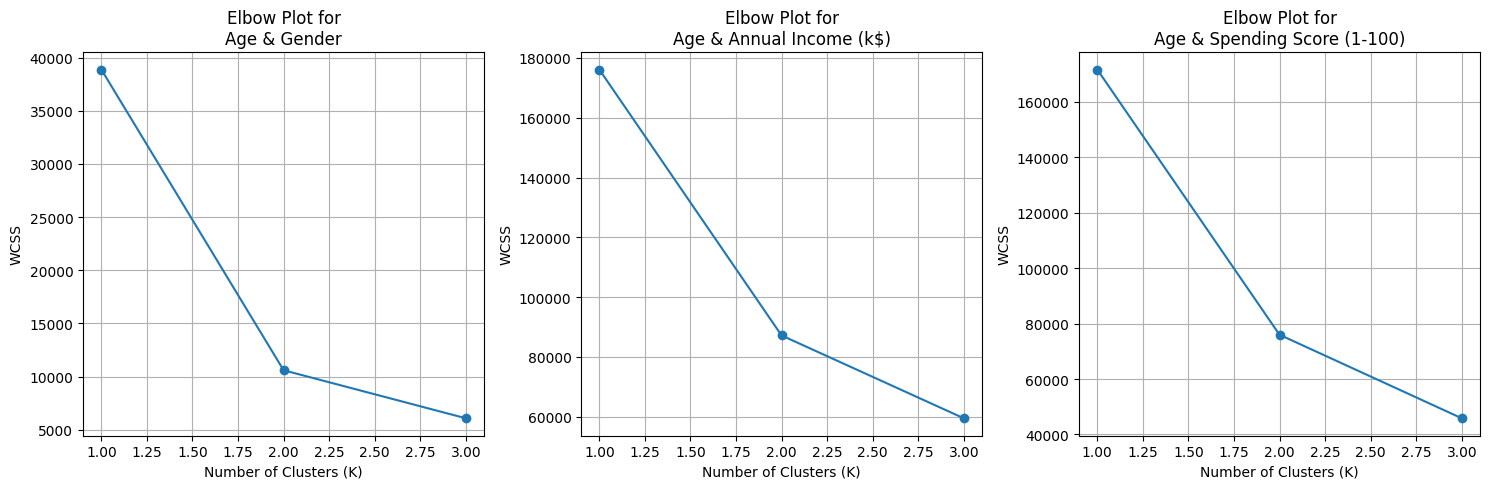

In [34]:
individual_attributes = ['Age', 'Gender', 'Annual Income (k$)', 'Spending Score (1-100)']
attribute_pairs = [
    ['Age', 'Gender'],
    ['Age', 'Annual Income (k$)'],
    ['Age', 'Spending Score (1-100)']
]


plt.figure(figsize=(20, 5))

for i, attr in enumerate(individual_attributes):
    # Lấy dữ liệu cho từng thuộc tính
    X_attr = df[attr].values.reshape(-1, 1)

    # Tính toán WCSS cho các giá trị K khác nhau
    wcss = []
    max_clusters = 3  # Số cụm tối đa để thử

    for k in range(1, max_clusters + 1):
        centroids, labels = kmeans(X_attr, K=k)
        wcss.append(compute_wcss(X_attr, centroids, labels))

    # Vẽ Elbow plot
    plt.subplot(1, 4, i+1)
    plt.plot(range(1, max_clusters + 1), wcss, marker='o')
    plt.title(f'Elbow Plot for\n{attr}')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('WCSS')
    plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

for i, attrs in enumerate(attribute_pairs):
    # Lấy dữ liệu cho từng cặp thuộc tính
    X_attr = df[attrs].values

    # Tính toán WCSS cho các giá trị K khác nhau
    wcss = []
    max_clusters = 3  # Số cụm tối đa để thử

    for k in range(1, max_clusters + 1):
        centroids, labels = kmeans(X_attr, K=k)
        wcss.append(compute_wcss(X_attr, centroids, labels))

    # Vẽ Elbow plot
    plt.subplot(1, 3, i+1)
    plt.plot(range(1, max_clusters + 1), wcss, marker='o')
    plt.title(f'Elbow Plot for\n{" & ".join(attrs)}')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('WCSS')
    plt.grid(True)

plt.tight_layout()
plt.show()